### Hierarchical Multi-Agent Supervisor
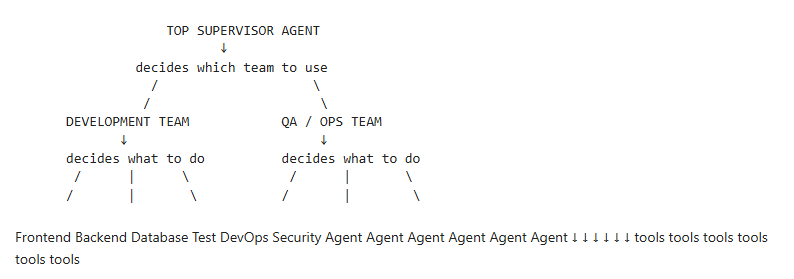

### development team

                        DEVELOPMENT TEAM LEAD
                         (decides strategy)
          ┌──────────────────────┼──────────────────────┐
          ▼                      ▼                      ▼
    FRONTEND AGENT         BACKEND AGENT          DATABASE AGENT
          ▼                      ▼                      ▼
     ┌──────────┐          ┌──────────┐          ┌──────────┐
     │ui        │          │api       │          │schema    │
     │components│          │logic     │          │migration │
     │styling   │          │routes    │          │queries   │
     │preview   │          │integrate │          │seed      │
     │testing   │          │validation│          │integrity │
     └──────────┘          └──────────┘          └──────────┘

### Qa team

                    QA / OPS TEAM LEAD
                     (decides strategy)
          ┌──────────────┼──────────────┐
          ▼              ▼              ▼
     TEST AGENT     DEVOPS AGENT   SECURITY AGENT
          ▼              ▼              ▼
     ┌────────┐    ┌──────────┐   ┌──────────┐
     │unit    │    │build     │   │sast      │
     │e2e     │    │cicd      │   │dast      │
     │visual  │    │iac/k8s   │   │secrets   │
     │coverage│    │observ.   │   │compliance│
     │reports │    │secrets   │   │incident  │
     └────────┘    └──────────┘   └──────────┘

In [34]:
# import
from typing import (
    TypedDict,
    Literal,
    Annotated,
)

import operator
import os
import json
from dotenv import load_dotenv
from pydantic import BaseModel

from langchain_openai import ChatOpenAI
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
)
from langchain_core.tools import tool
# from langchain.agents import create_agent

from langgraph.graph import (
    StateGraph,
    START,
    END,
    MessagesState,
)
from langgraph.types import (
    Command,
    Send,
)
from langgraph.checkpoint.memory import InMemorySaver

In [35]:
load_dotenv()

True

In [36]:
model = ChatOpenAI(
    model="nvidia/nemotron-3-ultra-550b-a55b:free",
    temperature=0,
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

### Architecture 2 — Software Development operation team.

In [37]:
from langgraph.graph import add_messages


class TeamState(TypedDict):
    """State shared across the multi-agent team workflow.
    
    Attributes:
        task: The original task or prompt given to the team.
        dev_output: Aggregated output from development team.
        qa_output: Aggregated output from QA team.
        message: List of messages exchanged between agents
    """
    task: str
    dev_output: str
    qa_output: str
    message: Annotated[list, add_messages]

### 1. development team in sequential workflow

In [38]:
def development_team_node(state: TeamState):
    """Development team: Lead plans -> Agents execute -> Writer aggregates."""
    task = state['task']

    # Step 1: LEAD creates plan (which agents needed)
    lead_prompt = f"""You are a Development Team Lead. Task: {task}

Decide which specialists are needed. Reply ONLY with JSON:
{{"agents": ["backend", "database"], "plan": "Brief plan for each agent"}}"""
    
    lead_response = model.invoke([HumanMessage(content=lead_prompt)])
    plan = json.loads(lead_response.content)
    agents = plan.get("agents", ["frontend", "backend", "database"])

    # Step 2: AGENTS execute (sequential)
    agent_prompts = {
        "frontend": f"Frontend Developer. Implement UI for: {task}",
        "backend": f"Backend Developer. Implement API for: {task}",
        "database": f"Database Engineer. Design schema for: {task}",
    }
    
    agent_outputs = {}
    for agent in agents:
        if agent in agent_prompts:
            response = model.invoke([HumanMessage(content=agent_prompts[agent])])
            agent_outputs[agent] = response.content

    # Step 3: WRITER aggregates into final report
    combined = "\n\n".join(f"{k.upper()}:\n{v}" for k, v in agent_outputs.items())
    
    writer_prompt = f"""You are the Development Team Writer.
    
    Combine these specialist outputs into a cohesive development report:
    
    {combined}"""
    
    writer_response = model.invoke([HumanMessage(content=writer_prompt)])

    return {"dev_output": writer_response.content}

### Qa team in parrallel workflow

In [39]:
# QA Team agents (receive dev_output via Send - partial state)
# QA Team agents (receive dev_output via Send)
def test_agent(state: TeamState):
    dev_output = state.get('dev_output', '')
    prompt = f"""You are a Test Engineer. Review the development output:
    {dev_output}
    
    Focus on: Unit tests, E2E tests, visual regression, coverage reports.
    Provide test strategy and specific test cases."""
    response = model.invoke([HumanMessage(content=prompt)])
    return {"message": [response]}

def devops_agent(state: TeamState):
    dev_output = state.get('dev_output', '')
    prompt = f"""You are a DevOps Engineer. Review the development output:
    {dev_output}
    
    Focus on: Building pipelines, CI/CD, infrastructure as code/K8s, observability, secrets management.
    Provide deployment and infrastructure strategy."""
    response = model.invoke([HumanMessage(content=prompt)])
    return {"message": [response]}

def security_agent(state: TeamState):
    dev_output = state.get('dev_output', '')
    prompt = f"""You are a Security Engineer. Review the development output:
    {dev_output}
    
    Focus on: SAST, DAST, secrets scanning, compliance, incident response.
    Provide security review and recommendations."""
    response = model.invoke([HumanMessage(content=prompt)])
    return {"message": [response]}

In [40]:
# QA Team coordinator - fans out to 3 agents in PARALLEL via Send
def aggregate_qa_outputs(state: TeamState):
    """Aggregates outputs from QA agents into single qa_output."""
    messages = state.get('message', [])
    aggregated = "\n\n".join([msg.content for msg in messages if isinstance(msg, AIMessage)])
    return {"qa_output": aggregated}

In [41]:
# Aggregate QA team outputs
def aggregate_qa_outputs(state: TeamState):
    """Aggregates outputs from QA agents into single qa_output."""
    messages = state.get('message', [])
    aggregated = "\n\n".join([msg.content for msg in messages if isinstance(msg, AIMessage)])
    return {"qa_output": aggregated}

### Top-supervisor state and nodes

In [42]:
def supervisor(state: TeamState) -> Command[Literal["dev_team", "qa_team", END]]:
    """Hierarchical supervisor: Dev Team -> QA Team -> END"""
    if not state.get('dev_output'):
        return Command(goto="dev_team")
    elif not state.get('qa_output'):
        return Command(goto="qa_team")
    return Command(goto=END)

### Build the Hierarchical Multi-Agent Graph

Graph compiled successfully!


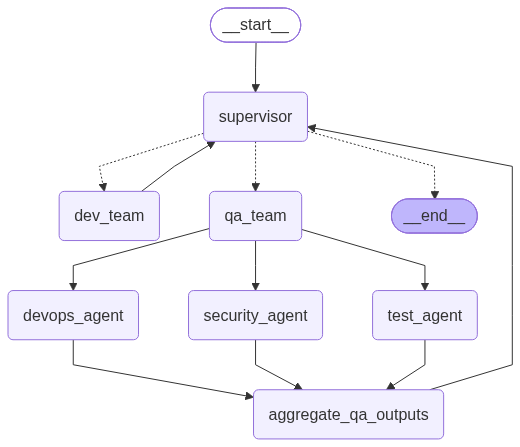

In [43]:
# Build the Hierarchical Multi-Agent Graph
builder = StateGraph(TeamState)

# Nodes
builder.add_node("supervisor", supervisor)
builder.add_node("dev_team", dev_team)
builder.add_node("qa_team", qa_team)
builder.add_node("test_agent", test_agent)
builder.add_node("devops_agent", devops_agent)
builder.add_node("security_agent", security_agent)
builder.add_node("aggregate_qa_outputs", aggregate_qa_outputs)

# Edges
builder.add_edge(START, "supervisor")

# Supervisor -> Dev Team
builder.add_edge("dev_team", "supervisor")

# Supervisor -> QA Team (coordinator)
builder.add_edge("qa_team", "test_agent")
builder.add_edge("qa_team", "devops_agent")
builder.add_edge("qa_team", "security_agent")

# QA agents -> Aggregator
builder.add_edge("test_agent", "aggregate_qa_outputs")
builder.add_edge("devops_agent", "aggregate_qa_outputs")
builder.add_edge("security_agent", "aggregate_qa_outputs")

# Aggregator -> Supervisor
builder.add_edge("aggregate_qa_outputs", "supervisor")

# Compile
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

print("Graph compiled successfully!")
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph: {e}")
    print("\nMermaid diagram:")
    print(graph.get_graph().draw_mermaid())

In [ ]:
# Test the Hierarchical Multi-Agent System
if __name__ == "__main__":
    task = "Build a user authentication system with login, registration, and password reset functionality"
    
    initial_state = {
        "task": task,
        "dev_output": "",
        "qa_output": "",
        "message": []
    }
    
    config = {"configurable": {"thread_id": "test-1"}}
    result = graph.invoke(initial_state, config=config)
    
    print("=" * 60)
    print("DEVELOPMENT TEAM OUTPUT")
    print("=" * 60)
    print(result.get('dev_output', 'No output'))
    
    print("\n" + "=" * 60)
    print("QA / OPS TEAM OUTPUT")
    print("=" * 60)
    print(result.get('qa_output', 'No output'))